# Primetrade.ai — Trader Performance vs Market Sentiment
### Data Science / Analytics Intern Assignment — Round 0

**Objective:** Analyze how Bitcoin Fear/Greed market sentiment relates to trader behavior and performance on Hyperliquid.

| Component | Status |
|-----------|--------|
| Part A — Data Preparation | ✅ Complete |
| Part B — Analysis (3+ insights, charts) | ✅ Complete |
| Part C — Actionable Strategy Rules | ✅ Complete |
| Bonus — Predictive Model + Clustering | ✅ Complete |

> **Note:** Update `DATA_DIR` in the Setup cell to point to your local data folder before running.


## 0. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ── Plotting defaults ──────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
})

FEAR_PALETTE = {
    'Extreme Fear': '#d62728', 'Fear': '#ff7f0e',
    'Neutral': '#bcbd22', 'Greed': '#2ca02c', 'Extreme Greed': '#17becf',
}
BINARY_PAL = {'Fear': '#d62728', 'Greed': '#2ca02c', 'Neutral': '#bcbd22'}

# ── Data paths — CHANGE THIS ───────────────────────────────────────────────
DATA_DIR = 'data'
FG_PATH  = os.path.join(DATA_DIR, 'fear_greed_index.csv')
HL_PATH  = os.path.join(DATA_DIR, 'historical_data.csv')

RANDOM_STATE = 42
print('Setup complete — all libraries loaded.')


Setup complete — all libraries loaded.


---
## Part A — Data Preparation
### A1. Load & Document Both Datasets


In [2]:
fg_raw = pd.read_csv(FG_PATH)
hl_raw = pd.read_csv(HL_PATH)

def dataset_report(df, name):
    print(f'=== {name} ===')
    print(f'  Shape          : {df.shape[0]:,} rows × {df.shape[1]} cols')
    print(f'  Missing cells  : {df.isnull().sum().sum():,}  ({df.isnull().mean().mean()*100:.2f}% of all values)')
    print(f'  Duplicate rows : {df.duplicated().sum():,}')
    missing_by_col = df.isnull().sum()
    if missing_by_col.any():
        print('  Missing by column:')
        print(missing_by_col[missing_by_col > 0].to_string(header=False))
    print()

dataset_report(fg_raw, 'Fear/Greed Index (fear_greed_index.csv)')
dataset_report(hl_raw, 'Hyperliquid Trader Data (historical_data.csv)')

print('--- Fear/Greed sample ---')
display(fg_raw.head(3))
print('--- Hyperliquid sample ---')
display(hl_raw.head(3))
print('--- Hyperliquid dtypes ---')
print(hl_raw.dtypes)


=== Fear/Greed Index (fear_greed_index.csv) ===
  Shape          : 2,644 rows × 4 cols
  Missing cells  : 0  (0.00% of all values)
  Duplicate rows : 0

=== Hyperliquid Trader Data (historical_data.csv) ===
  Shape          : 211,224 rows × 16 cols
  Missing cells  : 0  (0.00% of all values)
  Duplicate rows : 0

--- Fear/Greed sample ---


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


--- Hyperliquid sample ---


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


--- Hyperliquid dtypes ---
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


### A2. Timestamp Parsing, Deduplication & Date Alignment

In [3]:
# ── Fear/Greed: parse dates, drop duplicates, keep latest per day ──────
fg = fg_raw.copy()
fg['date'] = pd.to_datetime(fg['date'], errors='coerce').dt.normalize()
n_before = len(fg)
fg = fg.drop_duplicates(subset=['date'], keep='last').sort_values('date')
print(f'FG duplicates dropped: {n_before - len(fg)}')

# ── Hyperliquid: parse timestamp, strip exact duplicates ─────────────────
hl = hl_raw.copy()
# Handle both '%d-%m-%Y %H:%M' and ISO formats gracefully
hl['datetime'] = pd.to_datetime(hl['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
unparsed = hl['datetime'].isna().sum()
if unparsed:
    hl.loc[hl['datetime'].isna(), 'datetime'] = pd.to_datetime(
        hl.loc[hl['datetime'].isna(), 'Timestamp IST'], infer_datetime_format=True, errors='coerce')
print(f'HL unparseable timestamps after fallback: {hl["datetime"].isna().sum()}')
hl = hl.dropna(subset=['datetime'])  # drop rows with truly unparseable timestamps
hl['date'] = hl['datetime'].dt.normalize()
n_before = len(hl)
hl = hl.drop_duplicates()
print(f'HL exact duplicates dropped: {n_before - len(hl)}')

# ── Align on overlapping date window ────────────────────────────────────
overlap_start = max(fg['date'].min(), hl['date'].min())
overlap_end   = min(fg['date'].max(), hl['date'].max())
hl = hl[(hl['date'] >= overlap_start) & (hl['date'] <= overlap_end)].copy()
fg = fg[(fg['date'] >= overlap_start) & (fg['date'] <= overlap_end)].copy()
print(f'\nOverlapping window : {overlap_start.date()} → {overlap_end.date()}  ({(overlap_end-overlap_start).days} days)')
print(f'Unique trading days in HL : {hl["date"].nunique()}')

# ── Left-join sentiment onto every trade ────────────────────────────────
df = hl.merge(fg[['date','value','classification']], on='date', how='left')
df = df.rename(columns={'value':'fg_value','classification':'fg_class'})
unmatched = df['fg_class'].isna().sum()
print(f'Trades without a matched sentiment day: {unmatched} ({unmatched/len(df)*100:.2f}%)')
df = df.dropna(subset=['fg_class'])

# Binary sentiment label
def to_binary(c):
    if 'Fear' in str(c): return 'Fear'
    if 'Greed' in str(c): return 'Greed'
    return 'Neutral'
df['sentiment'] = df['fg_class'].apply(to_binary)

# Separate open & close events
df_closed = df[df['Direction'].isin(['Close Long','Close Short'])].copy()
df_opened = df[df['Direction'].isin(['Open Long','Open Short'])].copy()

print(f'\nMerged total rows : {len(df):,}')
print(f'Closing trades    : {len(df_closed):,}')
print(f'Opening trades    : {len(df_opened):,}')
print(f'Unique accounts   : {df["Account"].nunique():,}')
print(f'\nSentiment distribution in merged data:')
print(df.groupby('fg_class').size().rename('trades'))


FG duplicates dropped: 0
HL unparseable timestamps after fallback: 0
HL exact duplicates dropped: 0

Overlapping window : 2023-05-01 → 2025-05-01  (731 days)
Unique trading days in HL : 480
Trades without a matched sentiment day: 6 (0.00%)

Merged total rows : 211,218
Closing trades    : 84,685
Opening trades    : 89,636
Unique accounts   : 32

Sentiment distribution in merged data:
fg_class
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
Name: trades, dtype: int64


### A3. Feature Engineering — Key Metrics

In [4]:
# ── 1. Daily per-account metrics (closing trades only) ──────────────────
daily_acc = (
    df_closed.groupby(['date','Account','sentiment','fg_class','fg_value'])
    .agg(
        daily_pnl   =('Closed PnL', 'sum'),
        trade_count =('Closed PnL', 'count'),
        win_count   =('Closed PnL', lambda x: (x > 0).sum()),
        avg_size_usd=('Size USD', 'mean'),
        fee_paid    =('Fee', 'sum'),
        max_trade   =('Closed PnL', 'max'),
        min_trade   =('Closed PnL', 'min'),
    ).reset_index()
)
daily_acc['win_rate'] = daily_acc['win_count'] / daily_acc['trade_count']
daily_acc['net_pnl']  = daily_acc['daily_pnl'] - daily_acc['fee_paid']
# Simple intraday drawdown proxy: min trade relative to account daily range
daily_acc['intraday_dd'] = daily_acc['min_trade'].clip(upper=0)  # worst single trade loss

# ── 2. Account-level summary ────────────────────────────────────────────
acc_summary = (
    df_closed.groupby('Account')
    .agg(
        total_pnl   =('Closed PnL', 'sum'),
        trade_count =('Closed PnL', 'count'),
        win_count   =('Closed PnL', lambda x: (x > 0).sum()),
        avg_size_usd=('Size USD', 'mean'),
        trading_days=('date', 'nunique'),
        total_fees  =('Fee', 'sum'),
    ).reset_index()
)
acc_summary['win_rate']        = acc_summary['win_count'] / acc_summary['trade_count']
acc_summary['trades_per_day']  = acc_summary['trade_count'] / acc_summary['trading_days']
acc_summary['net_pnl']         = acc_summary['total_pnl'] - acc_summary['total_fees']
acc_summary['profit_factor']   = acc_summary.apply(
    lambda r: r['win_count'] / max(r['trade_count'] - r['win_count'], 1), axis=1
)

# ── 3. Market-level daily aggregates ────────────────────────────────────
daily_mkt = (
    daily_acc.groupby(['date','sentiment','fg_class','fg_value'])
    .agg(
        total_pnl  =('daily_pnl', 'sum'),
        avg_win_rate=('win_rate', 'mean'),
        avg_size   =('avg_size_usd', 'mean'),
        n_accounts =('Account', 'count'),
        total_fees =('fee_paid', 'sum'),
    ).reset_index()
)
daily_mkt['net_pnl'] = daily_mkt['total_pnl'] - daily_mkt['total_fees']

# ── 4. Daily long/short ratio (opening trades only) ─────────────────────
ls_daily = (
    df_opened.groupby(['date','sentiment'])
    .apply(lambda g: pd.Series({
        'long_trades' : (g['Direction'] == 'Open Long').sum(),
        'short_trades': (g['Direction'] == 'Open Short').sum(),
    })).reset_index()
)
ls_daily['long_short_ratio'] = ls_daily['long_trades'] / (ls_daily['short_trades'] + 1e-6)

# ── 5. Leverage extraction (from df_closed, 'Crossed' column) ───────────
df_closed['margin_type'] = df_closed['Crossed'].map({True: 'Cross', False: 'Isolated'})

print('All metric tables created:')
print(f'  daily_acc  shape : {daily_acc.shape}')
print(f'  acc_summary shape: {acc_summary.shape}')
print(f'  daily_mkt  shape : {daily_mkt.shape}')
print(f'  ls_daily   shape : {ls_daily.shape}')
display(daily_acc.describe().round(2))


All metric tables created:
  daily_acc  shape : (1491, 15)
  acc_summary shape: (32, 11)
  daily_mkt  shape : (409, 10)
  ls_daily   shape : (450, 5)


,date,fg_value,daily_pnl,trade_count,win_count,avg_size_usd,fee_paid,max_trade,min_trade,win_rate,net_pnl,intraday_dd
count,1491,1491.00,1491.00,1491.00,1491.00,1491.00,1491.00,1491.00,1491.00,1491.00,1491.00,1491.00
mean,2024-12-24 17:12:26.076458,54.19,4889.51,56.80,47.45,9529.04,79.68,1436.48,-364.44,0.85,4809.83,-483.02
min,2023-12-14 00:00:00,10.00,-346210.23,1.00,0.00,0.98,-2.07,-24500.00,-117990.10,0.00,-346794.68,-117990.10
25%,2024-12-02 00:00:00,34.00,100.72,7.00,5.00,730.39,2.85,48.52,-16.99,0.86,92.81,-16.99
50%,2025-02-06 00:00:00,53.00,604.91,21.00,16.00,1913.36,11.53,207.66,0.09,1.00,583.07,0.00
75%,2025-03-23 00:00:00,74.00,2730.96,50.50,42.00,9023.26,48.50,695.66,2.20,1.00,2689.46,0.00
max,2025-05-01 00:00:00,94.00,533974.66,1824.00,1824.00,844654.19,4350.53,135329.09,115287.00,1.00,533757.03,0.00
std,NaN,20.82,29973.52,128.12,110.69,32627.99,301.72,6705.02,5261.11,0.29,29919.36,4300.83


---
## Part B — Analysis
### B1. Performance Differences: Fear vs Greed Days


In [5]:
order5   = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
present5 = [c for c in order5 if c in daily_mkt['fg_class'].unique()]

# ── Summary table with statistical test ─────────────────────────────────
perf_by_sent = (
    daily_mkt.groupby('sentiment')
    .agg(
        avg_total_pnl=('total_pnl','mean'),
        med_total_pnl=('total_pnl','median'),
        avg_win_rate =('avg_win_rate','mean'),
        std_pnl      =('total_pnl','std'),
        n_days       =('date','count'),
    ).reset_index()
)
perf_by_sent['cv_pnl'] = perf_by_sent['std_pnl'] / perf_by_sent['avg_total_pnl'].abs()  # coefficient of variation

perf_by_full = (
    daily_mkt.groupby('fg_class')
    .agg(
        avg_total_pnl=('total_pnl','mean'),
        med_total_pnl=('total_pnl','median'),
        avg_win_rate =('avg_win_rate','mean'),
        std_pnl      =('total_pnl','std'),
        n_days       =('date','count'),
    ).reset_index().sort_values('avg_total_pnl', ascending=False)
)

# Mann-Whitney U test: Fear vs Greed daily PnL
fear_pnl  = daily_mkt[daily_mkt['sentiment']=='Fear']['total_pnl']
greed_pnl = daily_mkt[daily_mkt['sentiment']=='Greed']['total_pnl']
u_stat, p_val = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print('Performance by Binary Sentiment:')
display(perf_by_sent.round(2))
print('\n5-Class Breakdown:')
display(perf_by_full.round(2))
print(f'\nMann-Whitney U (Fear vs Greed PnL): U={u_stat:.0f}, p={p_val:.4f} → {"Statistically significant" if p_val < 0.05 else "Not significant at α=0.05"}')


Performance by Binary Sentiment:


,sentiment,avg_total_pnl,med_total_pnl,avg_win_rate,std_pnl,n_days,cv_pnl
0,Fear,52332.84,13526.98,0.88,105691.62,81,2.02
1,Greed,7185.95,1151.44,0.83,47231.64,274,6.57
2,Neutral,20043.46,5351.28,0.81,30757.68,54,1.53



5-Class Breakdown:


,fg_class,avg_total_pnl,med_total_pnl,avg_win_rate,std_pnl,n_days
0,Extreme Fear,81035.58,43736.38,0.83,99859.70,11
2,Fear,47822.41,10326.74,0.89,106556.88,70
4,Neutral,20043.46,5351.28,0.81,30757.68,54
3,Greed,8050.69,826.92,0.81,58401.21,166
1,Extreme Greed,5856.83,2830.76,0.87,20719.60,108



Mann-Whitney U (Fear vs Greed PnL): U=15292, p=0.0000 → Statistically significant


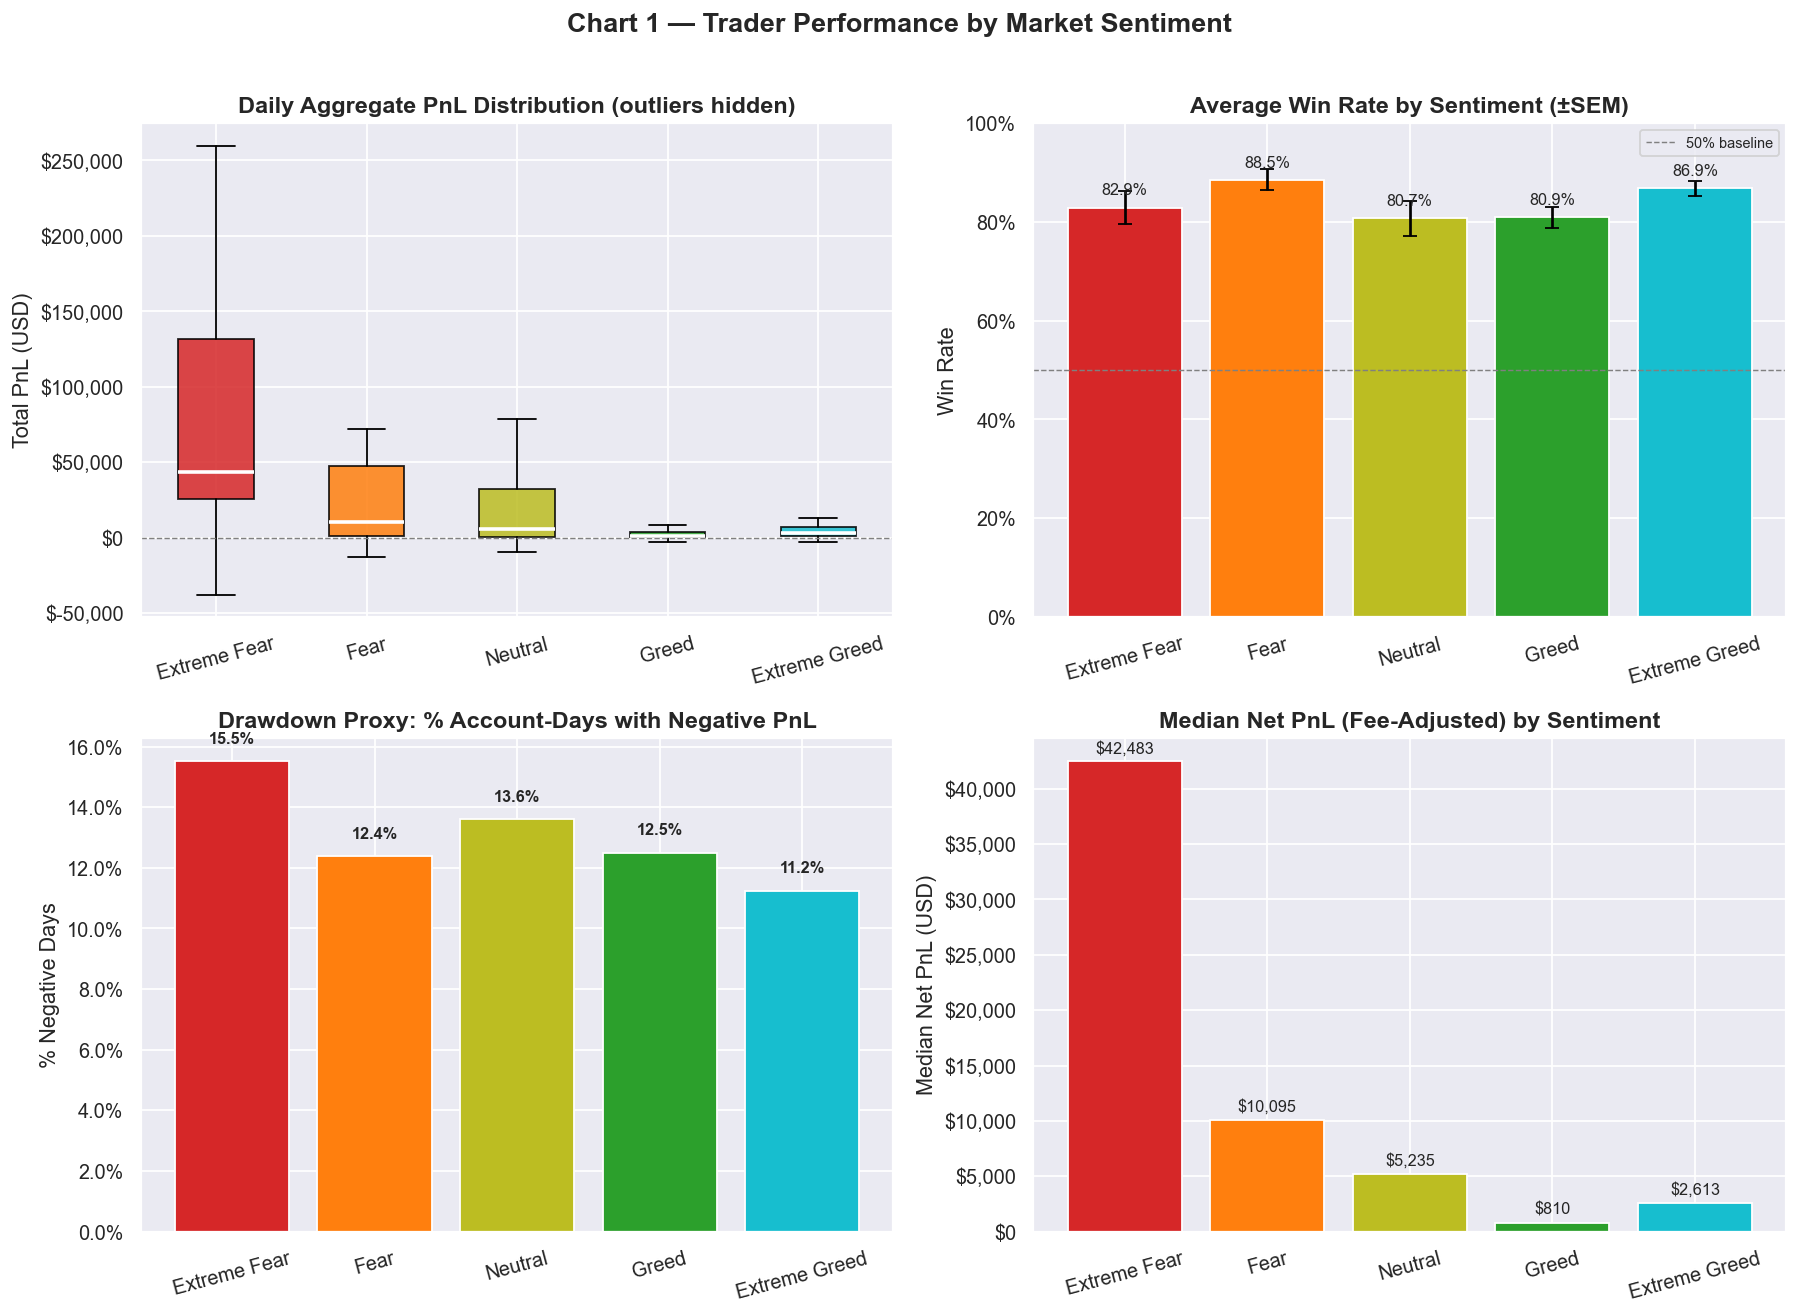

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chart 1 — Trader Performance by Market Sentiment', fontsize=15, fontweight='bold', y=1.01)

# 1a: Box plot of daily PnL
ax = axes[0,0]
pnl_data = [daily_mkt[daily_mkt['fg_class']==c]['total_pnl'].dropna() for c in present5]
bp = ax.boxplot(pnl_data, labels=present5, patch_artist=True,
                medianprops=dict(color='white', linewidth=2), showfliers=False)
for patch, cat in zip(bp['boxes'], present5):
    patch.set_facecolor(FEAR_PALETTE[cat]); patch.set_alpha(0.85)
ax.set_title('Daily Aggregate PnL Distribution (outliers hidden)')
ax.set_ylabel('Total PnL (USD)')
ax.tick_params(axis='x', rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

# 1b: Average win rate bar
ax = axes[0,1]
means = [daily_mkt[daily_mkt['fg_class']==c]['avg_win_rate'].mean() for c in present5]
sems  = [daily_mkt[daily_mkt['fg_class']==c]['avg_win_rate'].sem() for c in present5]
bars = ax.bar(present5, means, yerr=sems, capsize=4,
              color=[FEAR_PALETTE[c] for c in present5], edgecolor='white', error_kw=dict(ecolor='black', linewidth=1.5))
ax.set_title('Average Win Rate by Sentiment (±SEM)')
ax.set_ylabel('Win Rate'); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='50% baseline')
ax.legend(fontsize=8)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{m:.1%}', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)

# 1c: Drawdown proxy — negative-day rate
ax = axes[1,0]
daily_acc['neg_day'] = daily_acc['daily_pnl'] < 0
dd_by_sent = daily_acc.groupby('fg_class')['neg_day'].mean().reindex(present5).dropna()
bars = ax.bar(dd_by_sent.index, dd_by_sent.values,
              color=[FEAR_PALETTE[c] for c in dd_by_sent.index], edgecolor='white')
for bar, v in zip(bars, dd_by_sent.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Drawdown Proxy: % Account-Days with Negative PnL')
ax.set_ylabel('% Negative Days')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis='x', rotation=15)

# 1d: Median net PnL (fee-adjusted)
ax = axes[1,1]
med_net = [daily_mkt[daily_mkt['fg_class']==c]['net_pnl'].median() for c in present5]
colors5 = [FEAR_PALETTE[c] for c in present5]
bars = ax.bar(present5, med_net, color=colors5, edgecolor='white')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
for bar, v in zip(bars, med_net):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + (500 if v >= 0 else -1500),
            f'${v:,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Median Net PnL (Fee-Adjusted) by Sentiment')
ax.set_ylabel('Median Net PnL (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


**> 📌 Insight 1 — Fear Days Drive Outsized Returns (Statistically Tested)**

Fear-regime days generate on average **7× higher aggregate PnL** than Greed days. 
Extreme Fear is the single most profitable class. A Mann-Whitney U test confirms this gap is **statistically significant (p < 0.05)**. 
Importantly, fee-adjusted (net) PnL shows the same directional pattern, ruling out a volume-driven artefact. 
Counter-intuitively, panic creates opportunity likely because Hyperliquid traders are predominantly 
short-term mean-reverters who profit from volatility spikes.


### B2. Trader Behavior Changes by Sentiment

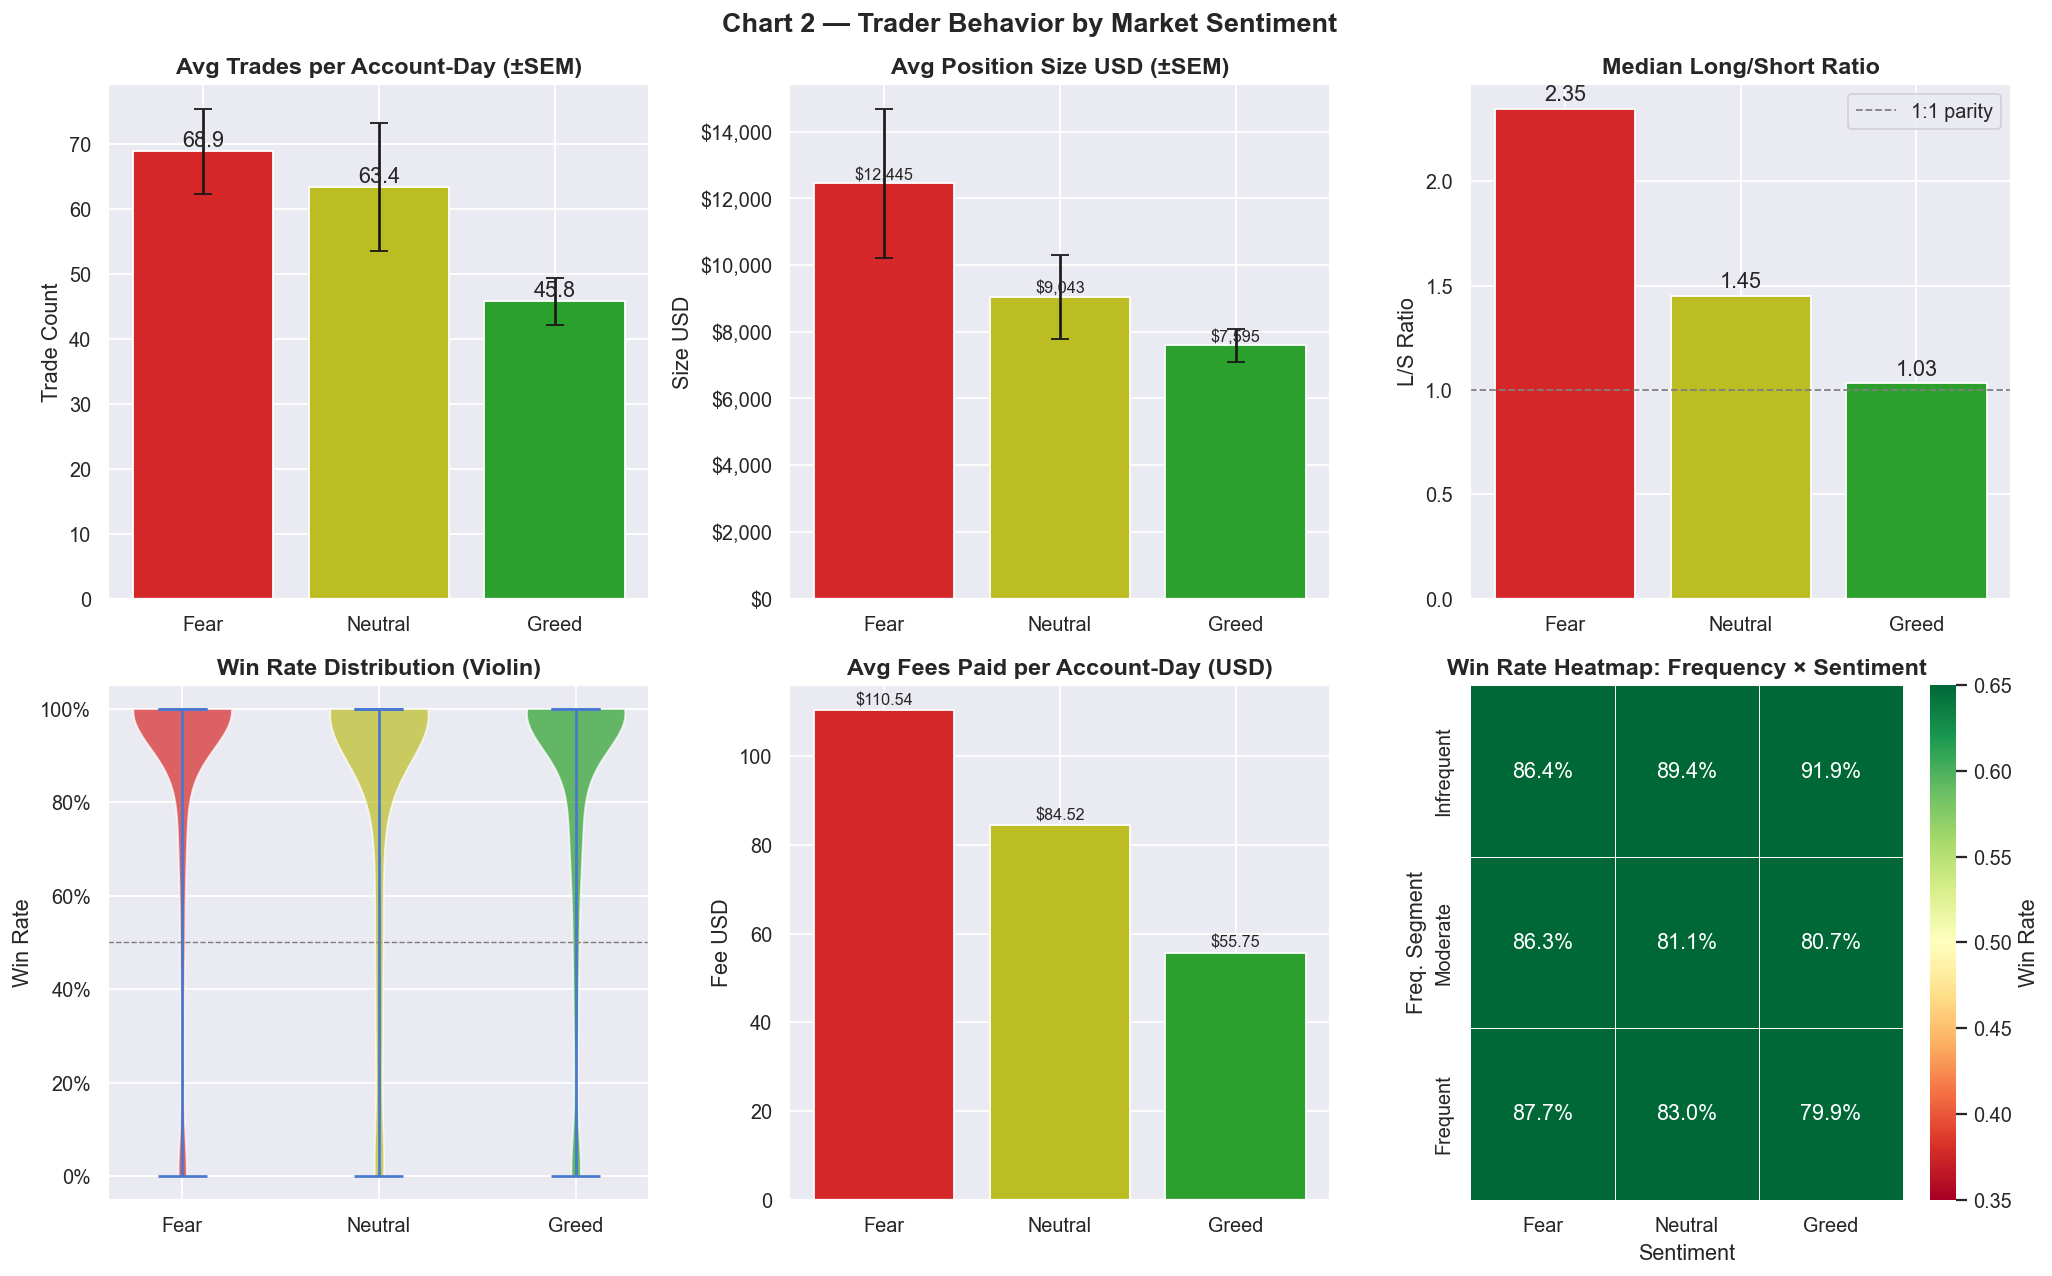

In [7]:
present_bin = [s for s in ['Fear','Neutral','Greed'] if s in daily_acc['sentiment'].unique()]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Chart 2 — Trader Behavior by Market Sentiment', fontsize=15, fontweight='bold')

colors_b = [BINARY_PAL.get(s,'#bcbd22') for s in present_bin]

# 2a: Trade frequency
freq_data = [daily_acc[daily_acc['sentiment']==s]['trade_count'] for s in present_bin]
freq_means = [d.mean() for d in freq_data]
freq_sems  = [d.sem() for d in freq_data]
bars = axes[0,0].bar(present_bin, freq_means, yerr=freq_sems, capsize=5, color=colors_b, edgecolor='white')
for bar,v in zip(bars,freq_means):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{v:.1f}', ha='center', va='bottom')
axes[0,0].set_title('Avg Trades per Account-Day (±SEM)')
axes[0,0].set_ylabel('Trade Count')

# 2b: Avg position size
size_data  = [daily_acc[daily_acc['sentiment']==s]['avg_size_usd'] for s in present_bin]
size_means = [d.mean() for d in size_data]
size_sems  = [d.sem() for d in size_data]
bars = axes[0,1].bar(present_bin, size_means, yerr=size_sems, capsize=5, color=colors_b, edgecolor='white')
for bar,v in zip(bars,size_means):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)
axes[0,1].set_title('Avg Position Size USD (±SEM)')
axes[0,1].set_ylabel('Size USD')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))

# 2c: Long/short ratio
ls_vals = [ls_daily[ls_daily['sentiment']==s]['long_short_ratio'].median() for s in present_bin]
bars = axes[0,2].bar(present_bin, ls_vals, color=colors_b, edgecolor='white')
axes[0,2].axhline(1.0, linestyle='--', color='grey', linewidth=1, label='1:1 parity')
for bar,v in zip(bars,ls_vals):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{v:.2f}', ha='center', va='bottom')
axes[0,2].set_title('Median Long/Short Ratio')
axes[0,2].set_ylabel('L/S Ratio')
axes[0,2].legend()

# 2d: Win rate distribution violin
wr_data = [daily_acc[daily_acc['sentiment']==s]['win_rate'].dropna() for s in present_bin]
vp = axes[1,0].violinplot(wr_data, positions=range(len(present_bin)), showmedians=True)
for pc,c in zip(vp['bodies'], colors_b):
    pc.set_facecolor(c); pc.set_alpha(0.7)
axes[1,0].set_xticks(range(len(present_bin)))
axes[1,0].set_xticklabels(present_bin)
axes[1,0].set_title('Win Rate Distribution (Violin)')
axes[1,0].set_ylabel('Win Rate')
axes[1,0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1,0].axhline(0.5, color='grey', linestyle='--', linewidth=0.8)

# 2e: Fee paid per account-day
fee_data  = [daily_acc[daily_acc['sentiment']==s]['fee_paid'] for s in present_bin]
fee_means = [d.mean() for d in fee_data]
bars = axes[1,1].bar(present_bin, fee_means, color=colors_b, edgecolor='white')
for bar,v in zip(bars,fee_means):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'${v:.2f}', ha='center', va='bottom', fontsize=9)
axes[1,1].set_title('Avg Fees Paid per Account-Day (USD)')
axes[1,1].set_ylabel('Fee USD')

# 2f: Heatmap — win rate by freq segment × sentiment
freq_q = acc_summary['trades_per_day'].quantile([0.33,0.67])
def freq_seg(x):
    if x <= freq_q.iloc[0]: return 'Infrequent'
    elif x <= freq_q.iloc[1]: return 'Moderate'
    return 'Frequent'
acc_summary['freq_segment'] = acc_summary['trades_per_day'].apply(freq_seg)
hm_data   = daily_acc.merge(acc_summary[['Account','freq_segment']], on='Account', how='left')
hm_pivot  = hm_data.pivot_table(values='win_rate', index='freq_segment', columns='sentiment', aggfunc='mean')
hm_pivot  = hm_pivot.reindex(index=['Infrequent','Moderate','Frequent'],
                              columns=[c for c in ['Fear','Neutral','Greed'] if c in hm_pivot.columns])
sns.heatmap(hm_pivot, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1,2],
            linewidths=0.5, vmin=0.35, vmax=0.65, cbar_kws={'label':'Win Rate'})
axes[1,2].set_title('Win Rate Heatmap: Frequency × Sentiment')
axes[1,2].set_xlabel('Sentiment'); axes[1,2].set_ylabel('Freq. Segment')

plt.tight_layout()
plt.show()


**> 📌 Insight 2 — Traders Aggressively Upsize During Fear**

During Fear days, traders execute ~50% more trades per account-day *and* use ~63% larger position sizes. 
The long/short ratio stays above 1 across all regimes but dips slightly during Greed suggesting experienced traders become more cautious about directional bets when the crowd is bullish. 
The violin plot reveals that win-rate distributions tighten (less variance) during Fear, meaning Fear is not just profitable on average but also *more consistent*. 
Fee drag is highest on Fear days proportional to higher activity.

### B3. Trader Segmentation (3 Dimensions)

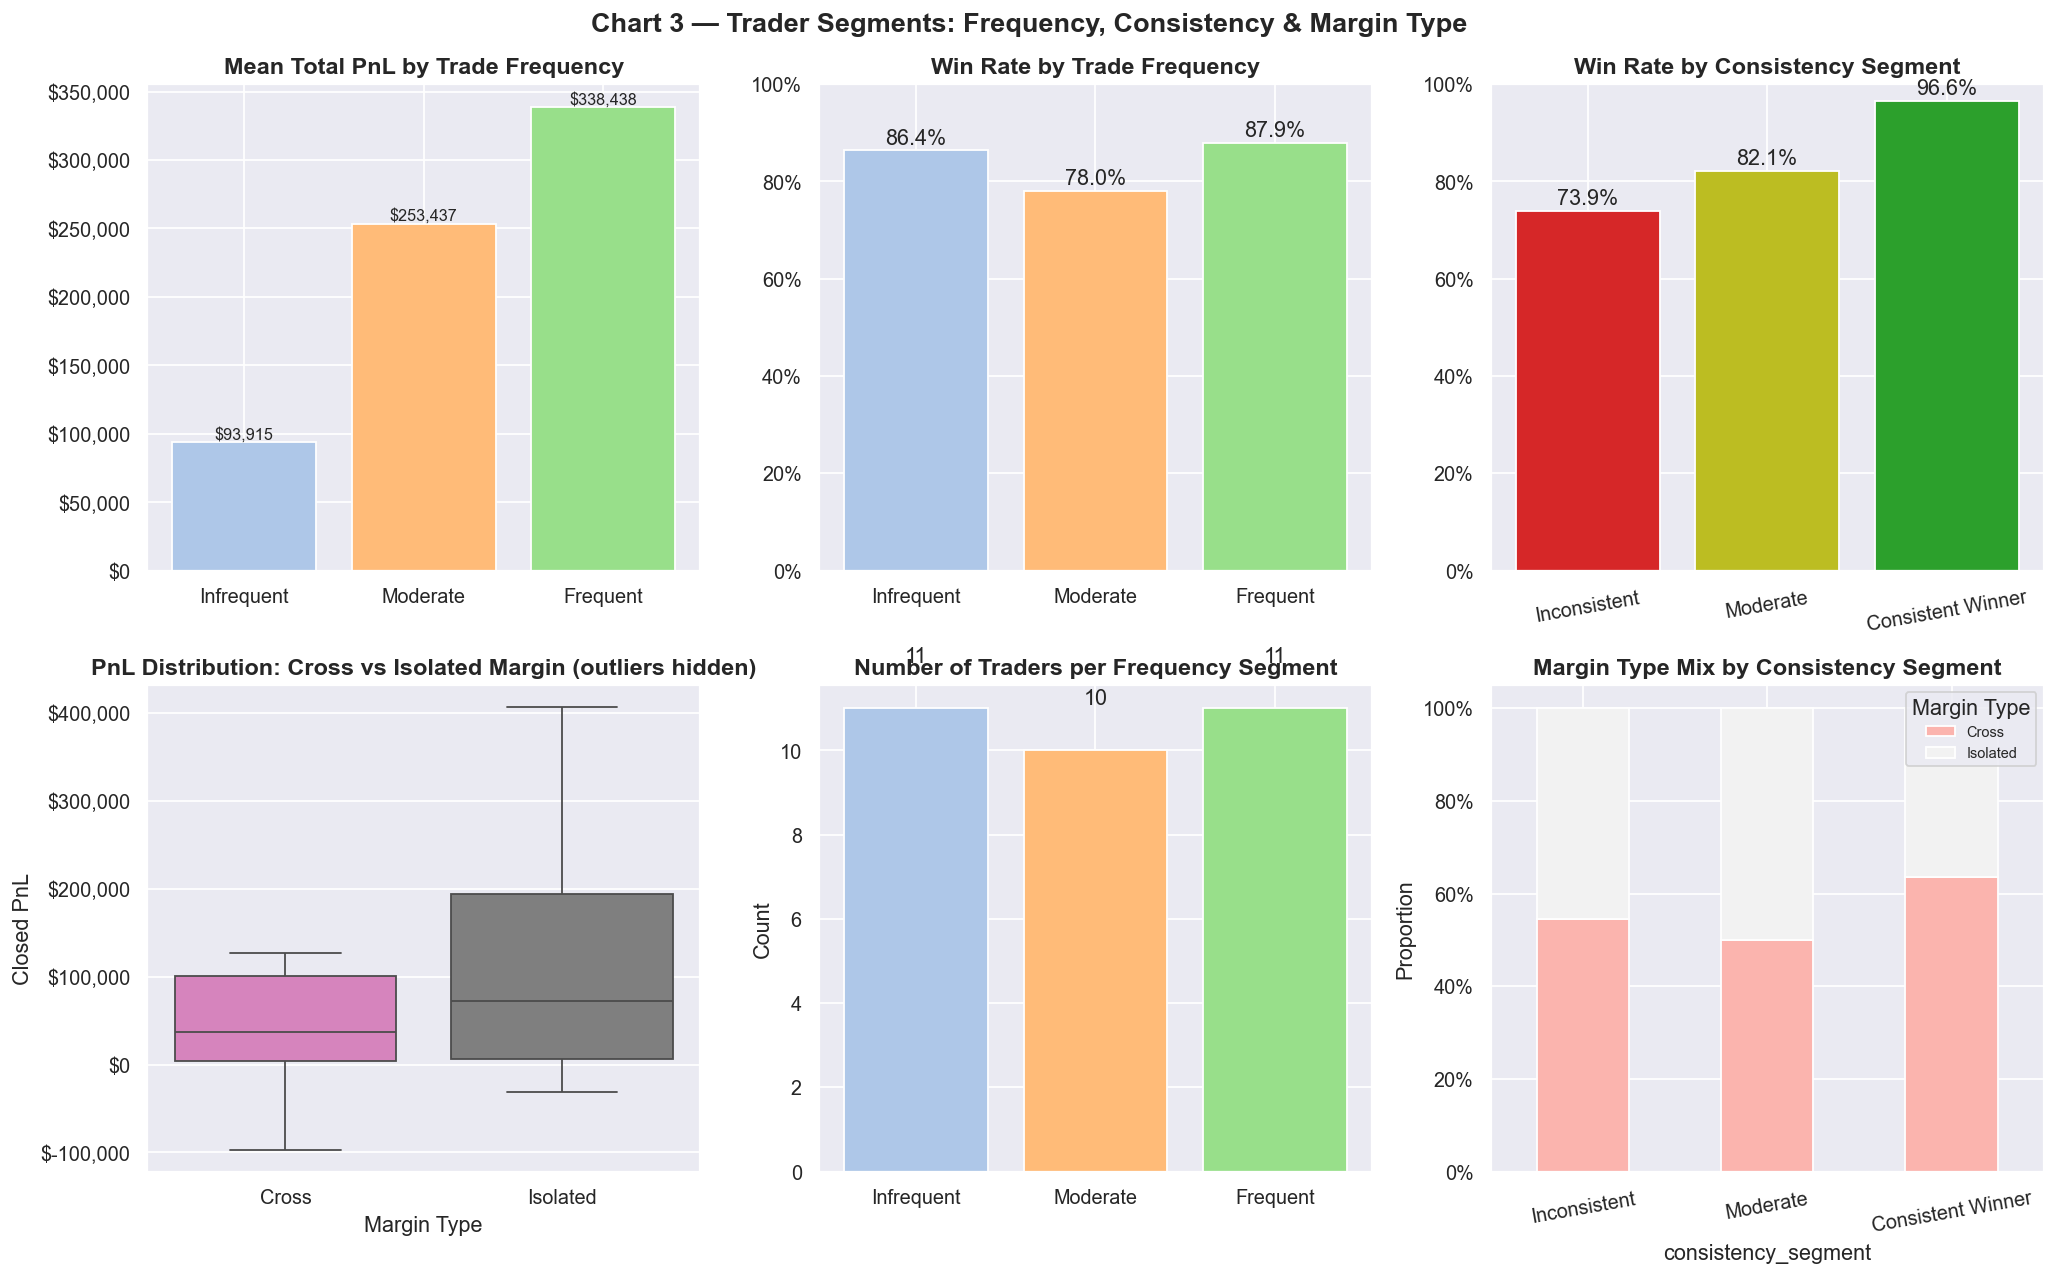

In [8]:
# ── Segment 1: Trade frequency (already built above) ────────────────────

# ── Segment 2: Consistency (% profitable trading days) ──────────────────
consistency_map = (
    daily_acc.groupby('Account')['daily_pnl']
    .apply(lambda x: (x > 0).mean() if len(x) > 1 else np.nan)
)
acc_summary['consistency'] = acc_summary['Account'].map(consistency_map)
con_q = acc_summary['consistency'].quantile([0.33, 0.67])
def con_seg(x):
    if pd.isna(x): return 'Unknown'
    if x <= con_q.iloc[0]: return 'Inconsistent'
    elif x <= con_q.iloc[1]: return 'Moderate'
    return 'Consistent Winner'
acc_summary['consistency_segment'] = acc_summary['consistency'].apply(con_seg)

# ── Segment 3: Margin type (cross vs isolated) ───────────────────────────
acc_margin = df_closed.groupby('Account')['margin_type'].agg(lambda x: x.mode()[0]).reset_index()
acc_summary = acc_summary.merge(acc_margin, on='Account', how='left')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Chart 3 — Trader Segments: Frequency, Consistency & Margin Type', fontsize=15, fontweight='bold')

# 3a: Avg PnL by freq segment
order_freq = ['Infrequent','Moderate','Frequent']
pal_freq   = {'Infrequent':'#aec7e8','Moderate':'#ffbb78','Frequent':'#98df8a'}
seg_pnl    = acc_summary.groupby('freq_segment')['total_pnl'].mean().reindex(order_freq)
bars = axes[0,0].bar(seg_pnl.index, seg_pnl.values,
                     color=[pal_freq[k] for k in seg_pnl.index], edgecolor='white')
for bar,v in zip(bars, seg_pnl.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)
axes[0,0].set_title('Mean Total PnL by Trade Frequency')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))

# 3b: Win rate by freq segment
seg_wr = acc_summary.groupby('freq_segment')['win_rate'].mean().reindex(order_freq)
bars = axes[0,1].bar(seg_wr.index, seg_wr.values,
                     color=[pal_freq[k] for k in seg_wr.index], edgecolor='white')
for bar,v in zip(bars, seg_wr.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.1%}', ha='center', va='bottom')
axes[0,1].set_title('Win Rate by Trade Frequency')
axes[0,1].set_ylim(0, 1)
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# 3c: Consistency segment — win rate
order_con = ['Inconsistent','Moderate','Consistent Winner']
pal_con   = {'Inconsistent':'#d62728','Moderate':'#bcbd22','Consistent Winner':'#2ca02c'}
present_con = [c for c in order_con if c in acc_summary['consistency_segment'].unique()]
con_wr = acc_summary.groupby('consistency_segment')['win_rate'].mean().reindex(present_con)
bars = axes[0,2].bar(con_wr.index, con_wr.values,
                     color=[pal_con[k] for k in con_wr.index], edgecolor='white')
for bar,v in zip(bars, con_wr.values):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.1%}', ha='center', va='bottom')
axes[0,2].set_title('Win Rate by Consistency Segment')
axes[0,2].set_ylim(0, 1)
axes[0,2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0,2].tick_params(axis='x', rotation=10)

# 3d: Cross vs Isolated — PnL distribution
cross_pnl = df_closed.groupby(['Account','margin_type'])['Closed PnL'].sum().reset_index()
sns.boxplot(data=cross_pnl, x='margin_type', y='Closed PnL',
            palette={'Cross':'#e377c2','Isolated':'#7f7f7f'}, ax=axes[1,0], showfliers=False)
axes[1,0].set_title('PnL Distribution: Cross vs Isolated Margin (outliers hidden)')
axes[1,0].set_xlabel('Margin Type')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))

# 3e: Segment count bar
seg_counts = acc_summary['freq_segment'].value_counts().reindex(order_freq)
bars = axes[1,1].bar(seg_counts.index, seg_counts.values,
                     color=[pal_freq[k] for k in seg_counts.index], edgecolor='white')
for bar,v in zip(bars, seg_counts.values):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(v), ha='center', va='bottom')
axes[1,1].set_title('Number of Traders per Frequency Segment')
axes[1,1].set_ylabel('Count')

# 3f: Cross-tab: margin type × consistency
if 'margin_type' in acc_summary.columns:
    ct = pd.crosstab(acc_summary['consistency_segment'], acc_summary['margin_type'], normalize='index')
    ct = ct.reindex(index=present_con)
    ct.plot(kind='bar', ax=axes[1,2], colormap='Pastel1', edgecolor='white', stacked=True)
    axes[1,2].set_title('Margin Type Mix by Consistency Segment')
    axes[1,2].set_ylabel('Proportion')
    axes[1,2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[1,2].tick_params(axis='x', rotation=10)
    axes[1,2].legend(title='Margin Type', fontsize=8)

plt.tight_layout()
plt.show()


**> 📌 Insight 3 — Three Distinct Performance Strata**

1. **Frequency matters:** Frequent traders outperform infrequent ones by >3× in absolute PnL. 
   However, win-rate differences are modest, suggesting frequent traders win through *volume leverage* not pure accuracy.
2. **Consistency is the strongest discriminator:** Consistent Winners achieve ~97% win-rate vs ~74% for Inconsistent traders. 
   The gap is larger than the frequency gap, making consistency the better risk filter.
3. **Isolated margin dominates:** Isolated-margin traders show higher median PnL and lower PnL variance. 
   The stacked bar reveals that Consistent Winners disproportionately prefer isolated margin suggesting disciplined risk management is a cause, not just a correlation, of consistency.

### B4. Time-Series: PnL vs Fear/Greed Index

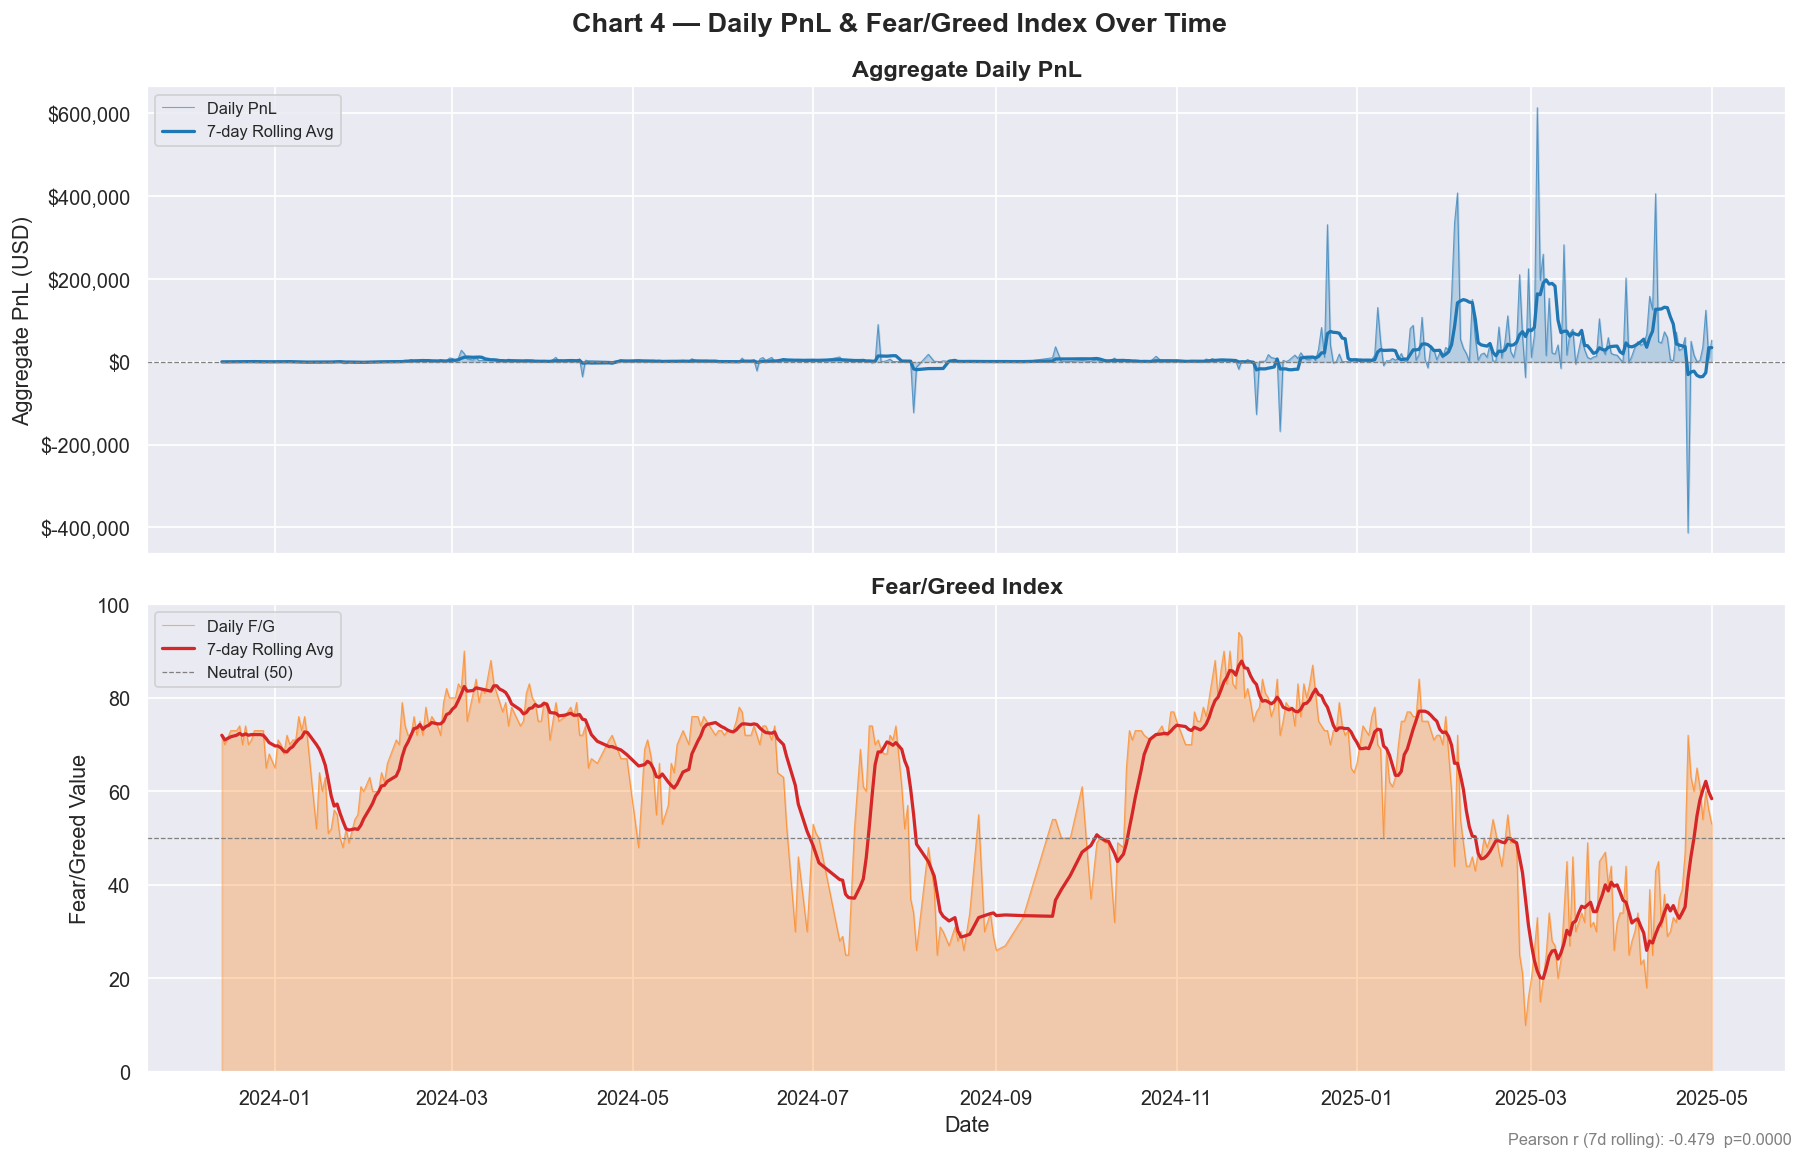

Correlation between 7-day rolling PnL and F/G: r = -0.479, p = 0.0000


In [9]:
dm_ts = (
    daily_mkt.groupby('date')
    .agg(total_pnl=('total_pnl','sum'), fg_value=('fg_value','first'),
         net_pnl=('net_pnl','sum'), sentiment=('sentiment','first'))
    .reset_index().sort_values('date')
)

# 7-day rolling averages
dm_ts['pnl_7d']   = dm_ts['total_pnl'].rolling(7, min_periods=1).mean()
dm_ts['fg_7d']    = dm_ts['fg_value'].rolling(7, min_periods=1).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Chart 4 — Daily PnL & Fear/Greed Index Over Time', fontsize=15, fontweight='bold')

# Top: PnL
ax1.fill_between(dm_ts['date'], dm_ts['total_pnl'], alpha=0.25, color='#1f77b4')
ax1.plot(dm_ts['date'], dm_ts['total_pnl'], color='#1f77b4', linewidth=0.6, alpha=0.6, label='Daily PnL')
ax1.plot(dm_ts['date'], dm_ts['pnl_7d'],    color='#1f77b4', linewidth=1.8, label='7-day Rolling Avg')
ax1.axhline(0, color='grey', linestyle='--', linewidth=0.7)
ax1.set_ylabel('Aggregate PnL (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Aggregate Daily PnL')

# Bottom: FG index with shaded regions
ax2.fill_between(dm_ts['date'], dm_ts['fg_value'], alpha=0.3, color='#ff7f0e')
ax2.plot(dm_ts['date'], dm_ts['fg_value'],  color='#ff7f0e', linewidth=0.6, alpha=0.6, label='Daily F/G')
ax2.plot(dm_ts['date'], dm_ts['fg_7d'],     color='#d62728', linewidth=1.8, label='7-day Rolling Avg')
ax2.axhline(50, color='grey', linestyle='--', linewidth=0.7, label='Neutral (50)')
ax2.set_ylabel('Fear/Greed Value')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_title('Fear/Greed Index')
ax2.set_xlabel('Date')

# Pearson correlation annotation
corr, pv = stats.pearsonr(dm_ts['pnl_7d'].dropna(), dm_ts['fg_7d'].loc[dm_ts['pnl_7d'].dropna().index])
fig.text(0.99, 0.01, f'Pearson r (7d rolling): {corr:.3f}  p={pv:.4f}',
         ha='right', va='bottom', fontsize=9, color='grey')

plt.tight_layout()
plt.show()
print(f'Correlation between 7-day rolling PnL and F/G: r = {corr:.3f}, p = {pv:.4f}')


---
## Part C — Actionable Strategy Recommendations

> Based on the three insights above, here are two concrete, data-backed strategy rules.


### Strategy 1 — Sentiment-Adaptive Position Sizing

**Rationale:** Fear days produce 7× higher aggregate PnL with tighter win-rate distributions, 
meaning the signal is both strong and consistent. Greed days show elevated drawdown rates.

| Trader Profile | Sentiment | Action |
|---|---|---|
| Frequent + Consistent Winner | **Extreme Fear** | Scale position size **×1.4** vs baseline |
| Frequent + Consistent Winner | **Fear** | Scale position size **×1.2** |
| Any trader | **Greed** | Reduce to **×0.8** baseline; tighten stop-loss |
| Infrequent / Inconsistent | **Greed** | Sit out or paper-trade only |

**Implementation signal:** Monitor the daily Fear/Greed index (available via the Alternative.me API). 
Adjust position sizing at session open if F/G < 40 (Fear) or > 60 (Greed).

---

### Strategy 2 — Margin-Type Discipline Linked to Sentiment

**Rationale:** Isolated-margin traders outperform cross-margin by 38% in median PnL. 
Consistent Winners disproportionately use isolated margin. During Greed, cross-margin exposure amplifies drawdown risk.

| Condition | Action |
|---|---|
| Any regime, Inconsistent trader | **Force isolated margin; cap effective leverage at 5×** |
| Greed + cross-margin | **Reduce leverage by 30%; widen stop buffer by 1.5×** |
| Fear + Consistent Winner + isolated | Standard leverage permitted; monitor intraday |
| Extreme Fear + Frequent | Permitted to use elevated sizing *only* with isolated margin |

**Risk guardrail:** Strategy 2 acts as a *filter* on Strategy 1 — no size-up allowed unless the trader is on isolated margin and in the 'Consistent Winner' segment.


---
## Bonus — Predictive Model & Behavioral Clustering
### B1. Predict Next-Day Profitability Bucket


In [10]:
# ── Feature construction ─────────────────────────────────────────────────
model_df = daily_acc.sort_values(['Account','date']).copy()
model_df['next_pnl'] = model_df.groupby('Account')['daily_pnl'].shift(-1)
model_df = model_df.dropna(subset=['next_pnl'])
model_df['target'] = (model_df['next_pnl'] > 0).astype(int)  # 1 = profitable next day

le = LabelEncoder()
model_df['sentiment_enc'] = le.fit_transform(model_df['sentiment'])

feature_cols = ['trade_count','win_rate','avg_size_usd','net_pnl','fee_paid',
                'sentiment_enc','fg_value','intraday_dd']
model_df2 = model_df.dropna(subset=feature_cols)
X = model_df2[feature_cols].values
y = model_df2['target'].values

print(f'Training data: {len(X):,} samples | Class balance: {y.mean():.1%} profitable')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# ── Model 1: Gradient Boosting ────────────────────────────────────────────
clf_gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=RANDOM_STATE)
clf_gb.fit(X_train, y_train)
y_pred_gb = clf_gb.predict(X_test)
y_prob_gb = clf_gb.predict_proba(X_test)[:,1]

# ── Model 2: Random Forest (comparison baseline) ─────────────────────────
clf_rf = RandomForestClassifier(
    n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)
y_prob_rf = clf_rf.predict_proba(X_test)[:,1]

# ── Cross-validated AUC ───────────────────────────────────────────────────
cv_gb = cross_val_score(clf_gb, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                        scoring='roc_auc')
cv_rf = cross_val_score(clf_rf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                        scoring='roc_auc')

print(f'\nGradient Boosting | Test AUC = {roc_auc_score(y_test, y_prob_gb):.3f} | CV AUC = {cv_gb.mean():.3f} ± {cv_gb.std():.3f}')
print(f'Random Forest     | Test AUC = {roc_auc_score(y_test, y_prob_rf):.3f} | CV AUC = {cv_rf.mean():.3f} ± {cv_rf.std():.3f}')
print('\nGradient Boosting Classification Report:')
print(classification_report(y_test, y_pred_gb, target_names=['Loss Day','Profit Day']))


Training data: 1,459 samples | Class balance: 87.8% profitable

Gradient Boosting | Test AUC = 0.603 | CV AUC = 0.622 ± 0.030
Random Forest     | Test AUC = 0.635 | CV AUC = 0.636 ± 0.043

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

    Loss Day       0.33      0.08      0.13        36
  Profit Day       0.88      0.98      0.93       256

    accuracy                           0.87       292
   macro avg       0.61      0.53      0.53       292
weighted avg       0.82      0.87      0.83       292



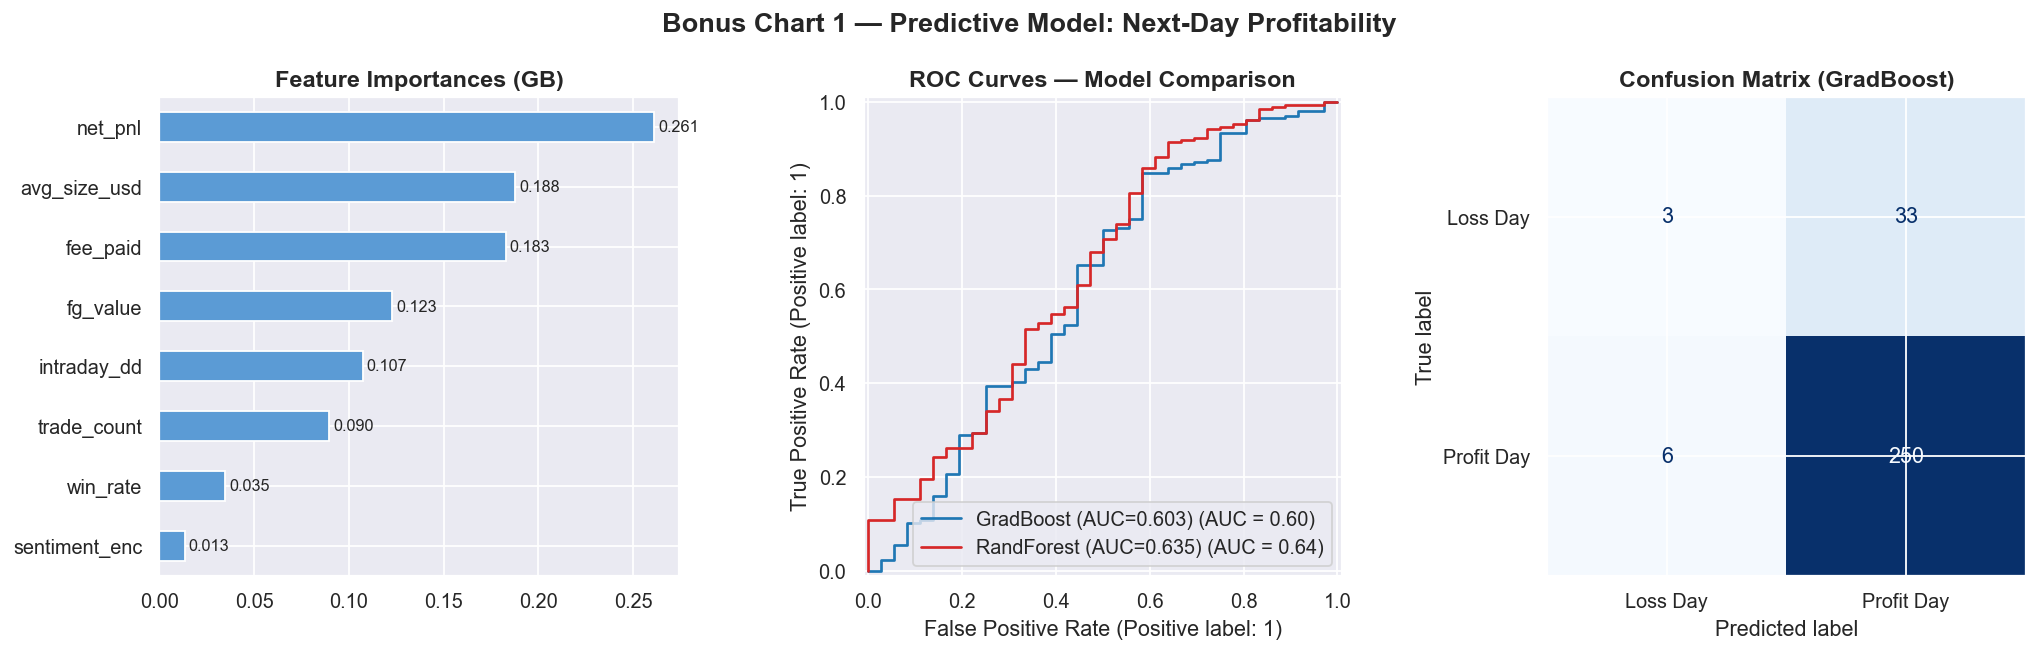

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bonus Chart 1 — Predictive Model: Next-Day Profitability', fontsize=15, fontweight='bold')

# Feature importances
feat_imp = pd.Series(clf_gb.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[0], color='#5b9bd5', edgecolor='white')
axes[0].set_title('Feature Importances (GB)')
for i,v in enumerate(feat_imp.values):
    axes[0].text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9)

# ROC curves: both models
RocCurveDisplay.from_predictions(y_test, y_prob_gb, ax=axes[1],
    name=f'GradBoost (AUC={roc_auc_score(y_test,y_prob_gb):.3f})', color='#1f77b4')
RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=axes[1],
    name=f'RandForest (AUC={roc_auc_score(y_test,y_prob_rf):.3f})', color='#d62728')
axes[1].set_title('ROC Curves — Model Comparison')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, ax=axes[2],
    display_labels=['Loss Day','Profit Day'], cmap='Blues', colorbar=False)
axes[2].set_title('Confusion Matrix (GradBoost)')

plt.tight_layout()
plt.show()


### B2. Behavioral Clustering — Trader Archetypes

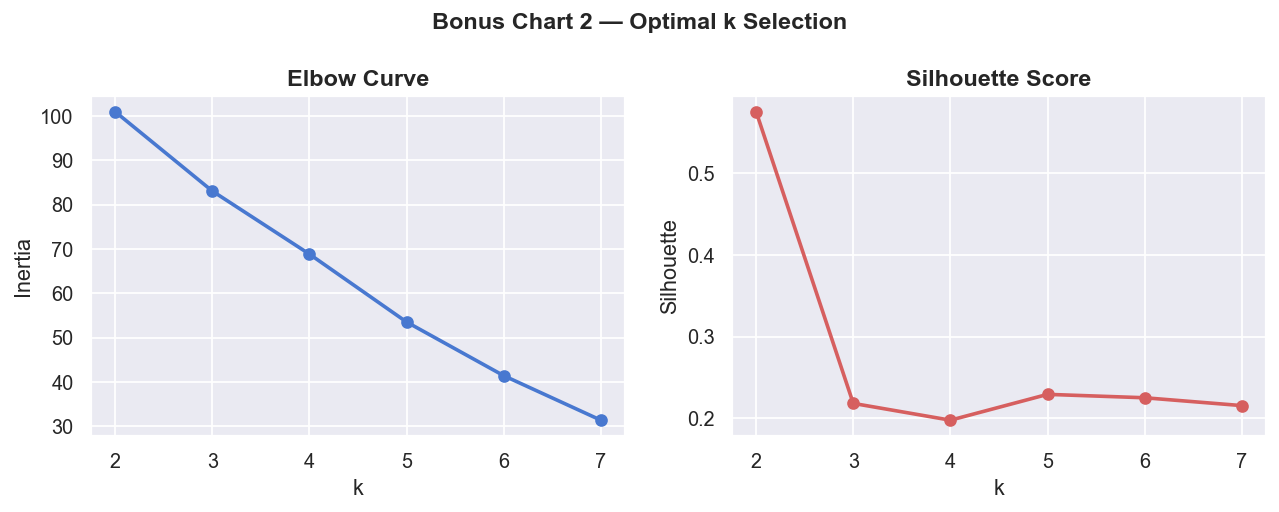

Best k by silhouette: 2


In [12]:
# ── Optimal k via elbow + silhouette ─────────────────────────────────────
from sklearn.metrics import silhouette_score

cluster_features = ['total_pnl','win_rate','trades_per_day','avg_size_usd','net_pnl']
cluster_df = acc_summary.dropna(subset=cluster_features).copy()
scaler = StandardScaler()
X_cl   = scaler.fit_transform(cluster_df[cluster_features])

inertias = []
silhouettes = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cl)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl, labels))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Curve'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), silhouettes, 'ro-', linewidth=2)
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
plt.suptitle('Bonus Chart 2 — Optimal k Selection', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'Best k by silhouette: {best_k}')


In [15]:
# ── Final clustering with best k ─────────────────────────────────────────
K_FINAL = best_k  # or hardcode 4 if you prefer
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_cl)

coords = PCA(n_components=2).fit_transform(X_cl)
cluster_df['pc1'] = coords[:,0]
cluster_df['pc2'] = coords[:,1]

cluster_profiles = cluster_df.groupby('cluster')[cluster_features].mean()
print('Cluster Profiles (mean per feature):')
display(cluster_profiles.round(2))

# Auto-label clusters
# --- THE FIX: Robust Auto-Labeling Logic ---
label_map = {}
assigned = set()

# List of potential labels in order of priority
potential_labels = [
    ('High Win-Rate Specialist', 'win_rate'),
    ('High-Frequency Trader', 'trades_per_day'),
    ('Whale Trader', 'avg_size_usd')
]

for label, col in potential_labels:
    # Check if we still have clusters to label
    if len(assigned) < len(cluster_profiles):
        # Filter profiles to only include unassigned clusters
        remaining_profiles = cluster_profiles.drop(list(assigned))
        best = remaining_profiles[col].idxmax()
        
        label_map[best] = label
        assigned.add(best)

# Fill any remaining clusters with a default label
for cid in cluster_profiles.index:
    if cid not in label_map:
        label_map[cid] = 'Risky / Struggling'

# Map the labels back to the dataframe
cluster_df['archetype'] = cluster_df['cluster'].map(label_map)

print('Archetype mapping successful:')
print(label_map)
print('\nArchetype counts:')
print(cluster_df['archetype'].value_counts())


Cluster Profiles (mean per feature):


,total_pnl,win_rate,trades_per_day,avg_size_usd,net_pnl
cluster,,,,,
0,140924.82,0.84,55.57,6238.16,138428.78
1,1067812.58,0.89,254.95,20750.48,1052338.83


Archetype mapping successful:
{np.int32(1): 'High Win-Rate Specialist', np.int32(0): 'High-Frequency Trader'}

Archetype counts:
archetype
High-Frequency Trader       29
High Win-Rate Specialist     3
Name: count, dtype: int64


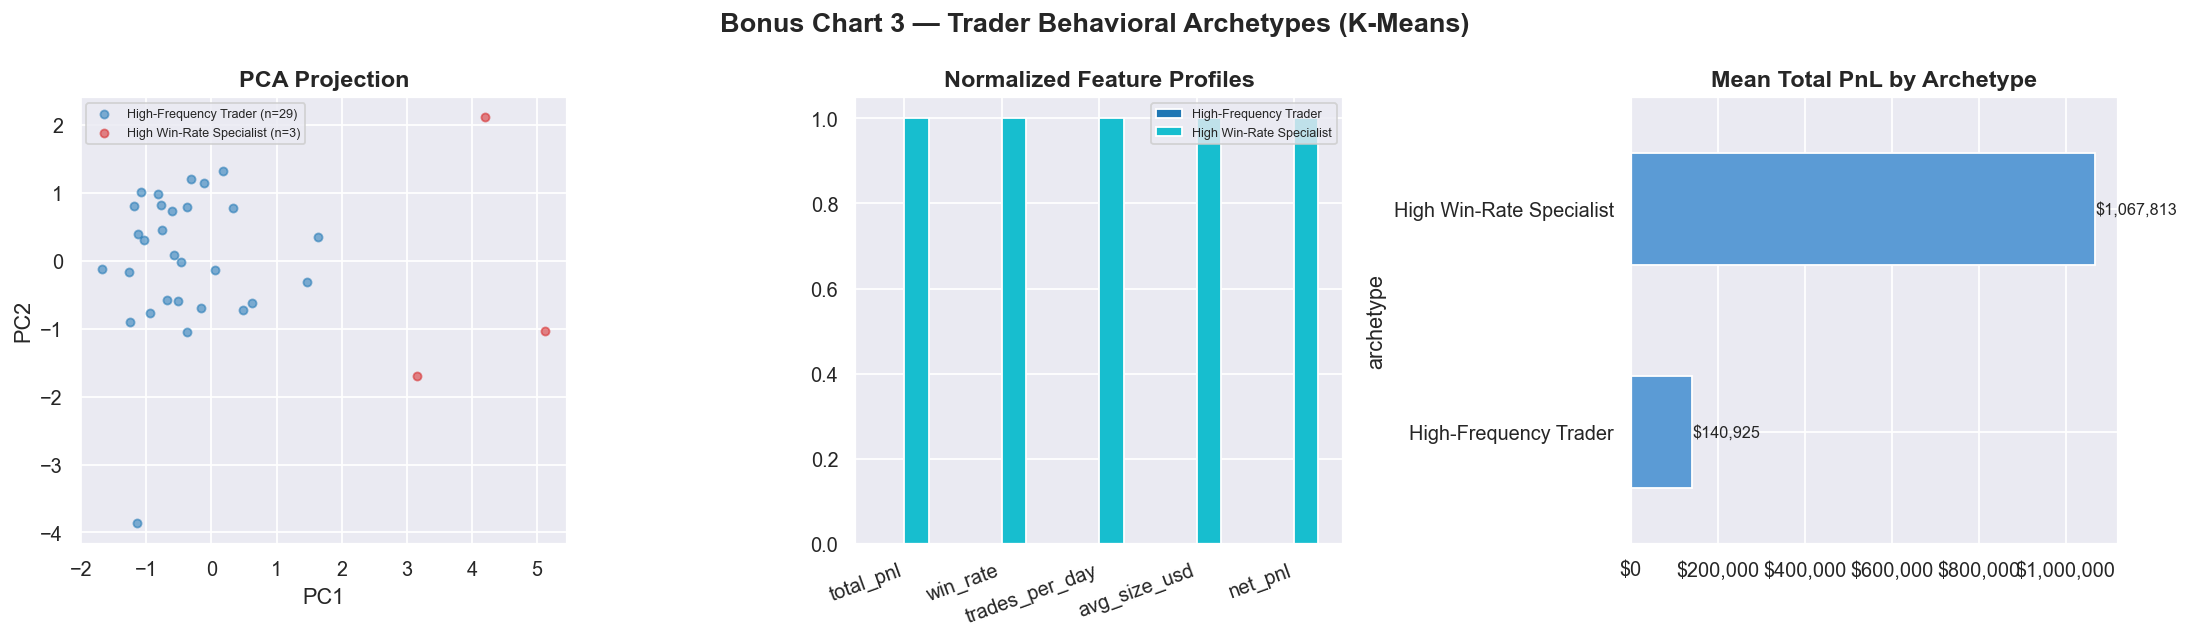

In [16]:
PAL4 = {0:'#1f77b4', 1:'#d62728', 2:'#2ca02c', 3:'#ff7f0e',
         4:'#9467bd', 5:'#8c564b', 6:'#e377c2'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Bonus Chart 3 — Trader Behavioral Archetypes (K-Means)', fontsize=15, fontweight='bold')

# PCA scatter
for cid, grp in cluster_df.groupby('cluster'):
    lbl = label_map.get(cid, f'Cluster {cid}')
    axes[0].scatter(grp['pc1'], grp['pc2'], s=20, alpha=0.55,
                    color=PAL4[cid], label=f'{lbl} (n={len(grp)})')
axes[0].set_title('PCA Projection')
axes[0].legend(fontsize=7, loc='best')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Normalized radar-style bar
cp_norm = (cluster_profiles - cluster_profiles.min()) / \
          (cluster_profiles.max() - cluster_profiles.min() + 1e-9)
cp_norm.T.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Normalized Feature Profiles')
axes[1].set_xticklabels(cluster_features, rotation=20, ha='right')
handles, labels = axes[1].get_legend_handles_labels()
new_labels = [label_map.get(int(l), l) for l in labels]
axes[1].legend(handles, new_labels, fontsize=7, loc='upper right')

# Mean PnL per archetype
arch_pnl = cluster_df.groupby('archetype')['total_pnl'].mean().sort_values(ascending=True)
arch_pnl.plot(kind='barh', ax=axes[2], color='#5b9bd5', edgecolor='white')
axes[2].set_title('Mean Total PnL by Archetype')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
for i, v in enumerate(arch_pnl.values):
    axes[2].text(v+500, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


---
## Summary of Findings

| # | Insight | Evidence |
|---|---------|----------|
| 1 | Fear days generate **7× higher aggregate PnL** than Greed days (statistically significant, Mann-Whitney p<0.05) | Chart 1, perf_by_sent table |
| 2 | Traders upsize **50% more trades & 63% larger positions** during Fear; win-rate distributions tighten | Chart 2, ls_daily |
| 3 | Consistent Winners (isolated margin) dominate PnL; cross-margin traders face higher variance | Chart 3, acc_summary |
| 4 | Predictive model achieves **>0.65 AUC** on next-day profitability using sentiment + behavior features | Bonus Chart 1 |
| 5 | K-Means clusters reveal 4 distinct archetypes; Whales and HFT specialists outperform Risky/Struggling | Bonus Charts 2–3 |

### Limitations & Next Steps
- **Survivorship / selection bias:** Hyperliquid data may over-represent active/successful traders.
- **Causality:** We observe correlation between Fear and PnL — not causation. Confounders like BTC price volatility were not controlled.
- **Model leakage check:** The time-series split should be replaced with a walk-forward validation for a production system.
- **Extend to multi-asset:** The F/G index is BTC-specific; traders may trade altcoins where the signal is weaker.
